<a href="https://colab.research.google.com/github/xanuragx-0/wind-power-prediction/blob/main/Comparision_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import scipy
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import  Sequential,layers, callbacks
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from math import sqrt
from numpy import concatenate
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

from pandas.plotting import register_matplotlib_converters
import seaborn as sns

from datetime import datetime
from sklearn.metrics import mean_squared_error

%matplotlib inline

# **WP Dataset**

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(1255)
df = pd.read_csv('WP.csv', index_col=0,header=0)
df.drop(['DewPointC', 'tempC','cloudcover','humidity','pressure'], axis=1,inplace=True)
df.dropna(inplace=True)
df.isnull().sum(axis = 0)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
# Splitting the dataset into the Training set and Test set
train_size = int(len(X) * 0.70)
test_size = len(X) - train_size
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test=y[:train_size], y[train_size:]
# Training the Random Forest Regression model on the whole dataset
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 45, random_state = 0)
regressor.fit(X_train, y_train)

df= pd.read_csv('WP.csv', index_col=0,header=0)
df.drop(['DewPointC', 'tempC','cloudcover','humidity','pressure'], axis=1,inplace=True)
df['Direction'].fillna(df['Direction'].mean(),inplace=True)
df.isnull().sum(axis = 0)
for i in range(len(df)):
  if (pd.isna(df.iloc[i,-1])):
    test_data=df.iloc[i,0:2].values
    test_data=test_data.reshape(-1,2)
    df.iloc[i,-1]=regressor.predict(test_data)

In [ ]:
tf.random.set_seed(1255)
# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('Energy', axis = 1)
y_train = train_dataset.loc[:,['Energy']]
# Split test data to X and y
X_test = test_dataset.drop('Energy', axis = 1)
y_test = test_dataset.loc[:,['Energy']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

Dimension of train data:  (36797, 3)
Dimension of test data:  (15771, 3)
(36797, 2)
(36797, 1)
(15771, 2)
(15771, 1)


## **MLR**

In [ ]:
########################################################################## MLR

# Training the Multiple Linear Regression model on the Training set
from sklearn.linear_model import LinearRegression
regressor_MLR = LinearRegression()
regressor_MLR.fit(X_train, y_train)

# Predicting the Test set results
y_pred = regressor_MLR.predict(X_test)

## **BILSTM, LSTM, GRU**

In [ ]:
#######################################################BILSTM, LSTM, GRU

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# Create BiLSTM model
def create_model_bilstm(units):
    model = Sequential()
    # First layer of BiLSTM
    model.add(Bidirectional(LSTM(units = units),input_shape=(X_train.shape[1], X_train.shape[2])))
    #model.add(Bidirectional(LSTM(units = units, return_sequences=True),input_shape=(X_train.shape[1], X_train.shape[2])))
    # Second layer of BiLSTM
    #model.add(Bidirectional(LSTM(units = units)))
    model.add(Dense(1,activation='linear'))
    #Compile model
    opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
    model.compile(loss='mse', optimizer=opt)
    return model



# Create LSTM or GRU model
def create_model(units, m):
    model = Sequential()
    # First layer of LSTM
    model.add(m (units = units, return_sequences = True, input_shape = [X_train.shape[1], X_train.shape[2]]))
    model.add(Dropout(0.2))
    # Second layer of LSTM
    model.add(m (units = units))
    model.add(Dropout(0.2))
    model.add(Dense(1,activation='linear'))
    #Compile model
    opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
    model.compile(loss='mse', optimizer=opt)
    return model

# Create stacked LSTM
def create_model_slstm(m):
  model = Sequential()
  model.add(m (units = 16, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  model.add(m (units = 16, return_sequences = True))
  model.add(Dropout(0.2))
  model.add(m (units = 16))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model


#Stacked LSTM
model_SLSTM = create_model_slstm(LSTM)

# BiLSTM
model_bilstm = create_model_bilstm(16)

# GRU and LSTM
model_gru = create_model(16, GRU)


# Fit BiLSTM, LSTM and GRU
def fit_model(model):
    early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 10)
    # shuffle = False because the order of the data matters
    history = model.fit(X_train, y_train, epochs = 100, validation_data=(X_test,y_test),batch_size = 64, shuffle = False, callbacks = [early_stop])
    return history

print('******************BILSTM********************')
history_bilstm = fit_model(model_bilstm)

print('******************GRU********************')
history_gru = fit_model(model_gru)

print('******************SLSTM********************')
history_SLSTM = fit_model(model_SLSTM)

#Inverse  transform the target  variable
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
    prediction = model.predict(X_test)
    prediction = scaler_y.inverse_transform(prediction)
    return prediction


prediction_bilstm = prediction(model_bilstm)
prediction_gru = prediction(model_gru)
prediction_SLSTM = prediction(model_SLSTM)

X_train.shape:  (36788, 10, 2)
y_train.shape:  (36788, 1)
X_test.shape:  (15762, 10, 2)
y_test.shape:  (15762, 1)
******************BILSTM********************
Epoch 1/100
575/575 [==============================] - 18s 24ms/step - loss: 0.0270 - val_loss: 0.0290
Epoch 2/100
575/575 [==============================] - 10s 17ms/step - loss: 0.0159 - val_loss: 0.0264
Epoch 3/100
575/575 [==============================] - 5s 9ms/step - loss: 0.0130 - val_loss: 0.0234
Epoch 4/100
575/575 [==============================] - 6s 10ms/step - loss: 0.0118 - val_loss: 0.0218
Epoch 5/100
575/575 [==============================] - 5s 9ms/step - loss: 0.0113 - val_loss: 0.0210
Epoch 6/100
575/575 [==============================] - 7s 12ms/step - loss: 0.0110 - val_loss: 0.0205
Epoch 7/100
575/575 [==============================] - 6s 10ms/step - loss: 0.0107 - val_loss: 0.0202
Epoch 8/100
575/575 [==============================] - 6s 11ms/step - loss: 0.0105 - val_loss: 0.0199
Epoch 9/100
575/575 [====

## **VAR**

In [ ]:
# Commented out IPython magic to ensure Python compatibility.
import numpy as np
import pandas as pd
# %matplotlib inline

# Load specific forecasting tools
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse

# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")
nobs=int(len(df)*0.3)
train, test = df[0:-nobs], df[-nobs:]

print(train.shape)
print(test.shape)
model_VAR = VAR(train)
results = model_VAR.fit(10)
lagged_values=train.values[-10:]
steps=len(test)
z=results.forecast(y=lagged_values,steps=len(test))
idx = pd.date_range('2018-03-14 06:00:00', periods=len(test), freq='H')
df_forecast = pd.DataFrame(z, index=idx, columns=['F_Speed (m/s)','F_Direction','F_Energy'])
var_f=df_forecast['F_Energy']

(36798, 3)
(15770, 3)


## **Combined Graph**

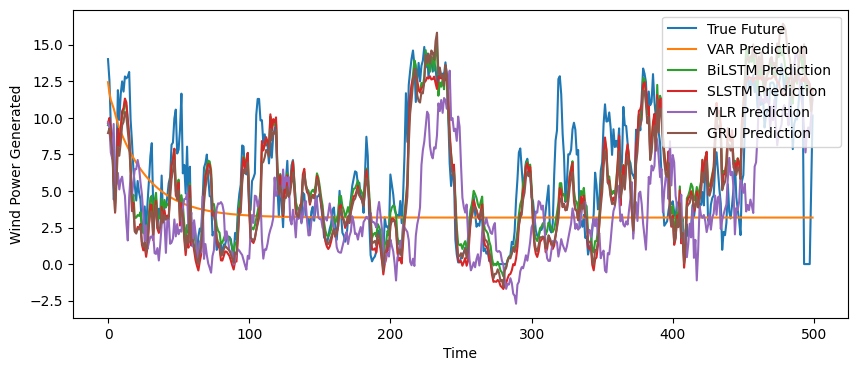

In [ ]:
######################################################################COMBINED GRAPH

plt.figure(figsize=(10, 4))
range_future =500
yt=np.array(y_test)
bilstm=np.array(prediction_bilstm)
gru=np.array(prediction_gru)
var=np.array(var_f)
MLR=np.array(y_pred)
slstm=np.array(prediction_SLSTM)

plt.plot(np.arange(range_future), yt[0:500],label='True Future')
plt.plot(np.arange(range_future),var[0:500],label='VAR Prediction ')
plt.plot(np.arange(range_future),bilstm[0:500],label='BiLSTM Prediction ')
plt.plot(np.arange(range_future),slstm[0:500],label='SLSTM Prediction ')
plt.plot(np.arange(range_future),MLR[0:500],label='MLR Prediction ')
plt.plot(np.arange(range_future),gru[0:500],label='GRU Prediction ')

plt.legend(loc='upper right')
plt.xlabel('Time')
plt.ylabel('Wind Power Generated')
plt.savefig('comaparision.png', dpi=1000, bbox_inches='tight')

## **Detailed Graph**

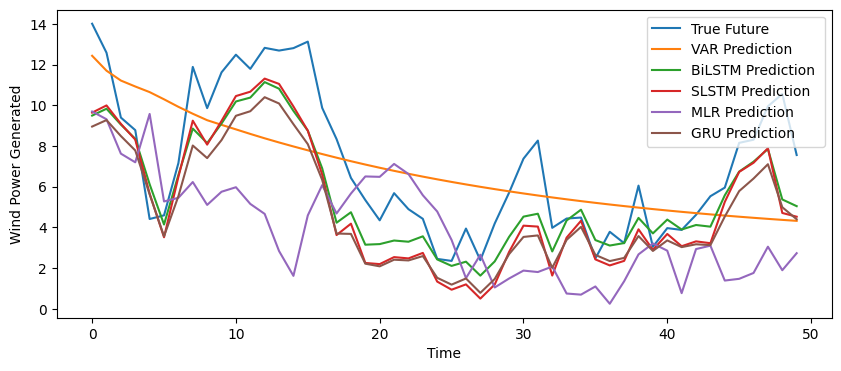

In [ ]:
plt.figure(figsize=(10, 4))
range_future =50
yt=np.array(y_test)
bilstm=np.array(prediction_bilstm)
gru=np.array(prediction_gru)
var=np.array(var_f)
MLR=np.array(y_pred)
slstm=np.array(prediction_SLSTM)

plt.plot(np.arange(range_future), yt[0:50],label='True Future')
plt.plot(np.arange(range_future),var[0:50],label='VAR Prediction ')
plt.plot(np.arange(range_future),bilstm[0:50],label='BiLSTM Prediction ')
plt.plot(np.arange(range_future),slstm[0:50],label='SLSTM Prediction ')
plt.plot(np.arange(range_future),MLR[0:50],label='MLR Prediction ')
plt.plot(np.arange(range_future),gru[0:50],label='GRU Prediction ')

plt.legend(loc='upper right')
plt.xlabel('Time')
plt.ylabel('Wind Power Generated')
plt.savefig('detailed_comaparision.png', dpi=1000, bbox_inches='tight')

# **T Dataset**

In [ ]:
df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.drop(['Theoretical_Power_Curve (KWh)'], axis=1,inplace=True)

# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(35371, 2)
(35371, 1)
(15159, 2)
(15159, 1)


## **MLR**

In [ ]:
# Training the Multiple Linear Regression model on the Training set
from sklearn.linear_model import LinearRegression
regressor_MLR = LinearRegression()
regressor_MLR.fit(X_train, y_train)

# Predicting the Test set results
y_pred = regressor_MLR.predict(X_test)

## **BILSTM, LSTM, GRU**

In [ ]:
#######################################################BILSTM, LSTM, GRU

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# Create BiLSTM model
def create_model_bilstm(units):
    model = Sequential()
    # First layer of BiLSTM
    model.add(Bidirectional(LSTM(units = units),input_shape=(X_train.shape[1], X_train.shape[2])))
    #model.add(Bidirectional(LSTM(units = units, return_sequences=True),input_shape=(X_train.shape[1], X_train.shape[2])))
    # Second layer of BiLSTM
    #model.add(Bidirectional(LSTM(units = units)))
    model.add(Dense(1,activation='linear'))
    #Compile model
    opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
    model.compile(loss='mse', optimizer=opt)
    return model



# Create LSTM or GRU model
def create_model(units, m):
    model = Sequential()
    # First layer of LSTM
    model.add(m (units = units, return_sequences = True, input_shape = [X_train.shape[1], X_train.shape[2]]))
    model.add(Dropout(0.2))
    # Second layer of LSTM
    model.add(m (units = units))
    model.add(Dropout(0.2))
    model.add(Dense(1,activation='linear'))
    #Compile model
    opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
    model.compile(loss='mse', optimizer=opt)
    return model

# Create stacked LSTM
def create_model_slstm(m):
  model = Sequential()
  model.add(m (units = 16, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  model.add(m (units = 16, return_sequences = True))
  model.add(Dropout(0.2))
  model.add(m (units = 16))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model


#Stacked LSTM
model_SLSTM = create_model_slstm(LSTM)

# BiLSTM
model_bilstm = create_model_bilstm(16)

# GRU and LSTM
model_gru = create_model(16, GRU)


# Fit BiLSTM, LSTM and GRU
def fit_model(model):
    early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 10)
    # shuffle = False because the order of the data matters
    history = model.fit(X_train, y_train, epochs = 100, validation_data=(X_test,y_test),batch_size = 64, shuffle = False, callbacks = [early_stop])
    return history

print('******************BILSTM********************')
history_bilstm = fit_model(model_bilstm)

print('******************GRU********************')
history_gru = fit_model(model_gru)

print('******************SLSTM********************')
history_SLSTM = fit_model(model_SLSTM)

#Inverse  transform the target  variable
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
    prediction = model.predict(X_test)
    prediction = scaler_y.inverse_transform(prediction)
    return prediction


prediction_bilstm = prediction(model_bilstm)
prediction_gru = prediction(model_gru)
prediction_SLSTM = prediction(model_SLSTM)

X_train.shape:  (35362, 10, 2)
y_train.shape:  (35362, 1)
X_test.shape:  (15150, 10, 2)
y_test.shape:  (15150, 1)
******************BILSTM********************
Epoch 1/100
553/553 [==============================] - 11s 11ms/step - loss: 0.0416 - val_loss: 0.0264
Epoch 2/100
553/553 [==============================] - 6s 11ms/step - loss: 0.0259 - val_loss: 0.0208
Epoch 3/100
553/553 [==============================] - 5s 8ms/step - loss: 0.0215 - val_loss: 0.0169
Epoch 4/100
553/553 [==============================] - 5s 9ms/step - loss: 0.0203 - val_loss: 0.0145
Epoch 5/100
553/553 [==============================] - 6s 11ms/step - loss: 0.0197 - val_loss: 0.0136
Epoch 6/100
553/553 [==============================] - 5s 8ms/step - loss: 0.0192 - val_loss: 0.0131
Epoch 7/100
553/553 [==============================] - 6s 11ms/step - loss: 0.0188 - val_loss: 0.0127
Epoch 8/100
553/553 [==============================] - 5s 8ms/step - loss: 0.0184 - val_loss: 0.0124
Epoch 9/100
553/553 [=======

## **VAR**

In [ ]:
# Commented out IPython magic to ensure Python compatibility.
import numpy as np
import pandas as pd
# %matplotlib inline

# Load specific forecasting tools
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse

# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")
nobs=int(len(df)*0.3)
train, test = df[0:-nobs], df[-nobs:]

print(train.shape)
print(test.shape)
model_VAR = VAR(train)
results = model_VAR.fit(10)
lagged_values=train.values[-10:]
steps=len(test)
z=results.forecast(y=lagged_values,steps=len(test))
idx = pd.date_range('2018-03-14 06:00:00', periods=len(test), freq='H')
df_forecast = pd.DataFrame(z, index=idx, columns=['F_Speed (m/s)','F_Direction','F_Energy'])
var_f=df_forecast['F_Energy']

(35371, 3)
(15159, 3)


## **Combined Graph**

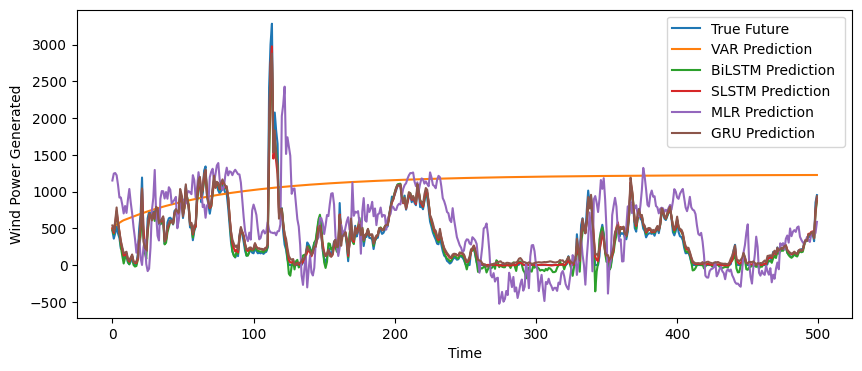

In [ ]:
######################################################################COMBINED GRAPH

plt.figure(figsize=(10, 4))
range_future =500
yt=np.array(y_test)
bilstm=np.array(prediction_bilstm)
gru=np.array(prediction_gru)
var=np.array(var_f)
MLR=np.array(y_pred)
slstm=np.array(prediction_SLSTM)

plt.plot(np.arange(range_future), yt[0:500],label='True Future')
plt.plot(np.arange(range_future),var[0:500],label='VAR Prediction ')
plt.plot(np.arange(range_future),bilstm[0:500],label='BiLSTM Prediction ')
plt.plot(np.arange(range_future),slstm[0:500],label='SLSTM Prediction ')
plt.plot(np.arange(range_future),MLR[0:500],label='MLR Prediction ')
plt.plot(np.arange(range_future),gru[0:500],label='GRU Prediction ')

plt.legend(loc='upper right')
plt.xlabel('Time')
plt.ylabel('Wind Power Generated')
plt.savefig('comaparisionT.png', dpi=1000, bbox_inches='tight')

## **Detailed Graph**

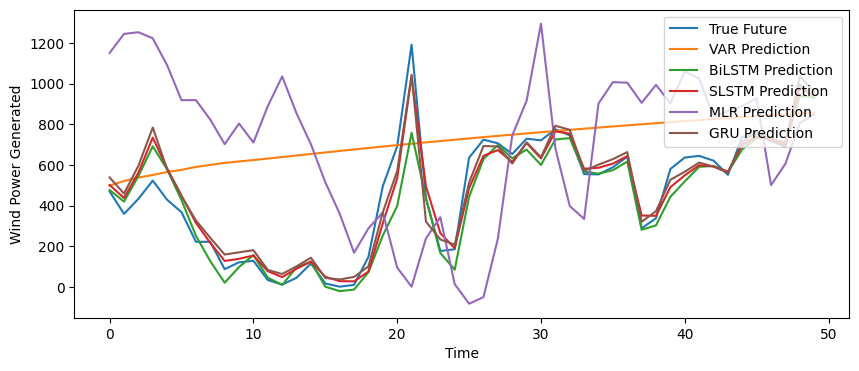

In [ ]:
plt.figure(figsize=(10, 4))
range_future =50
yt=np.array(y_test)
bilstm=np.array(prediction_bilstm)
gru=np.array(prediction_gru)
var=np.array(var_f)
MLR=np.array(y_pred)
slstm=np.array(prediction_SLSTM)

plt.plot(np.arange(range_future), yt[0:50],label='True Future')
plt.plot(np.arange(range_future),var[0:50],label='VAR Prediction ')
plt.plot(np.arange(range_future),bilstm[0:50],label='BiLSTM Prediction ')
plt.plot(np.arange(range_future),slstm[0:50],label='SLSTM Prediction ')
plt.plot(np.arange(range_future),MLR[0:50],label='MLR Prediction ')
plt.plot(np.arange(range_future),gru[0:50],label='GRU Prediction ')

plt.legend(loc='upper right')
plt.xlabel('Time')
plt.ylabel('Wind Power Generated')
plt.savefig('detailed_comaparisionT.png', dpi=1000, bbox_inches='tight')